In [1]:
import os
import gc
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.initializers import (
    Zeros,
    RandomNormal,
    GlorotUniform,
    HeNormal
)
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs("images", exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Seed:", SEED)

TensorFlow version: 2.20.0
Seed: 42


In [3]:
IMG_SIZE = (224, 224)
NUM_CLASSES = 37

BATCH_SIZE = 32

EPOCHS = 5
CV_EPOCHS = 3
FINE_TUNE_EPOCHS = 5

AUTOTUNE = tf.data.AUTOTUNE

DATASET_NAME = "oxford_iiit_pet"

print("Image size:", IMG_SIZE)
print("Classes:", NUM_CLASSES)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Classes: 37
Batch size: 32


In [4]:
train_raw, test_raw = tfds.load(
    DATASET_NAME,
    split=["train", "test"],
    as_supervised=True,
    shuffle_files=True,
   
)

print("Training examples:", tf.data.experimental.cardinality(train_raw).numpy())
print("Test examples:", tf.data.experimental.cardinality(test_raw).numpy())

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1787803546.076328      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787803546.079325      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Training examples: 3680
Test examples: 3669


In [5]:
TOTAL_TRAIN = tf.data.experimental.cardinality(train_raw).numpy()

VAL_COUNT = int(0.20 * TOTAL_TRAIN)
TRAIN_COUNT = TOTAL_TRAIN - VAL_COUNT

train_raw = train_raw.shuffle(
    TOTAL_TRAIN,
    seed=SEED,
    reshuffle_each_iteration=False
)

train_only_raw = train_raw.take(TRAIN_COUNT)
val_raw = train_raw.skip(TRAIN_COUNT)

print("Training:", TRAIN_COUNT)
print("Validation:", VAL_COUNT)
print("Independent Test:", tf.data.experimental.cardinality(test_raw).numpy())

Training: 2944
Validation: 736
Independent Test: 3669


In [6]:
def preprocess_image(image, label):

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = preprocess_input(image)

    label = tf.cast(
        label,
        tf.int32
    )

    return image, label

In [7]:
def make_dataset(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
):

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            1000,
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(
        batch_size
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [8]:
train_ds = make_dataset(
    train_only_raw,
    BATCH_SIZE,
    shuffle=True
)

val_ds = make_dataset(
    val_raw,
    BATCH_SIZE,
    shuffle=False
)

test_ds = make_dataset(
    test_raw,
    BATCH_SIZE,
    shuffle=False
)

print("Datasets created successfully.")

Datasets created successfully.


In [9]:
train_ds = make_dataset(
    train_only_raw,
    BATCH_SIZE,
    shuffle=True
)

val_ds = make_dataset(
    val_raw,
    BATCH_SIZE,
    shuffle=False
)

test_ds = make_dataset(
    test_raw,
    BATCH_SIZE,
    shuffle=False
)

print("Datasets created successfully.")

Datasets created successfully.


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>


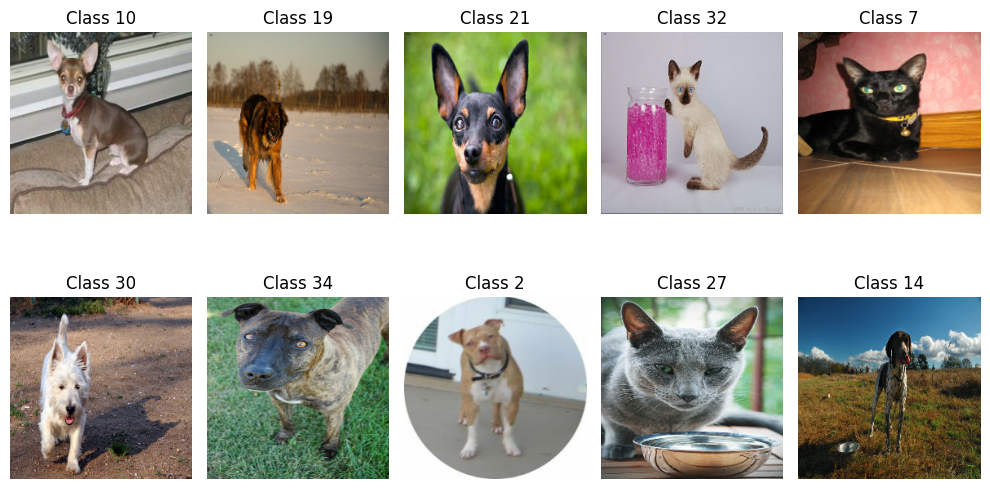

In [12]:
sample_images, sample_labels = next(
    iter(train_ds)
)

print("Batch image shape:", sample_images.shape)
print("Batch label shape:", sample_labels.shape)
print("Image dtype:", sample_images.dtype)
print("Label dtype:", sample_labels.dtype)
plt.figure(figsize=(10, 6))

for i in range(min(10, len(sample_images))):

    image = (sample_images[i].numpy() + 1.0) / 2.0

    plt.subplot(2, 5, i + 1)
    plt.imshow(np.clip(image, 0, 1))
    plt.title(f"Class {sample_labels[i].numpy()}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "sample_images.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [13]:
del sample_images
del sample_labels

gc.collect()

print("Initial memory cleanup completed.")

Initial memory cleanup completed.


In [14]:
def build_model(
    initializer=None,
    regularization=None,
    dropout=0.0,
    batch_norm=False,
    base_trainable=False,
    fine_tune_layers=0
):

    base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = False

    if base_trainable:

        if fine_tune_layers > 0:

            for layer in base.layers:
                layer.trainable = False

            for layer in base.layers[-fine_tune_layers:]:
                layer.trainable = True

        else:
            base.trainable = True

    inputs = layers.Input(
        shape=(224, 224, 3)
    )

    x = base(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    if batch_norm:
        x = layers.BatchNormalization()(x)

    if initializer is None:
        initializer = HeNormal()

    x = layers.Dense(
        128,
        activation="relu",
        kernel_initializer=initializer,
        kernel_regularizer=regularization
    )(x)

    if dropout > 0:
        x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_initializer=initializer
    )(x)

    model = Model(
        inputs,
        outputs
    )

    return model

In [15]:
def cleanup_model(model=None):

    if model is not None:
        del model

    tf.keras.backend.clear_session()
    gc.collect()

In [16]:
baseline_model = build_model()

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
baseline_start = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

baseline_time = time.time() - baseline_start

baseline_best_val = max(
    baseline_history.history["val_accuracy"]
)

print(
    f"\nBaseline best validation accuracy: "
    f"{baseline_best_val * 100:.2f}%"
)

print(
    f"Baseline training time: "
    f"{baseline_time:.2f} seconds"
)

Epoch 1/5


2026-08-27 04:08:15.507775: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 04:08:15.644113: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1787803697.524160     156 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 127ms/step - accuracy: 0.7357 - loss: 1.0402 - val_accuracy: 0.9280 - val_loss: 0.2367
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.9243 - loss: 0.2382 - val_accuracy: 0.9484 - val_loss: 0.1699
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9589 - loss: 0.1430 - val_accuracy: 0.9755 - val_loss: 0.0964
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.9732 - loss: 0.0969 - val_accuracy: 0.9864 - val_loss: 0.0596
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.9905 - loss: 0.0482 - val_accuracy: 0.9986 - val_loss: 0.0290

Baseline best validation accuracy: 99.86%
Baseline training time: 77.06 seconds


In [18]:
baseline_results = {
    "Configuration": "Baseline",
    "Best Validation Accuracy (%)": baseline_best_val * 100,
    "Training Time (s)": baseline_time,
    "Parameters": baseline_model.count_params()
}

baseline_results

{'Configuration': 'Baseline',
 'Best Validation Accuracy (%)': 99.8641312122345,
 'Training Time (s)': 77.05507349967957,
 'Parameters': 2426725}

In [19]:
initializers = {
    "Zero": Zeros(),
    "Random": RandomNormal(mean=0.0, stddev=0.05),
    "Xavier": GlorotUniform(seed=SEED),
    "He": HeNormal(seed=SEED)
}

initialization_histories = {}
initialization_results = {}

for name, initializer in initializers.items():

    print("\n" + "=" * 60)
    print("Initialization:", name)
    print("=" * 60)

    model = build_model(
        initializer=initializer
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    elapsed = time.time() - start

    initialization_histories[name] = history.history

    initialization_results[name] = {
        "Final Training Loss": history.history["loss"][-1],
        "Best Validation Accuracy":
            max(history.history["val_accuracy"]),
        "Training Time": elapsed
    }

    cleanup_model(model)


Initialization: Zero
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.0245 - loss: 3.6113 - val_accuracy: 0.0204 - val_loss: 3.6111
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.0255 - loss: 3.6112 - val_accuracy: 0.0272 - val_loss: 3.6106
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.0228 - loss: 3.6111 - val_accuracy: 0.0258 - val_loss: 3.6113
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.0251 - loss: 3.6111 - val_accuracy: 0.0353 - val_loss: 3.6106
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.0268 - loss: 3.6110 - val_accuracy: 0.0190 - val_loss: 3.6124

Initialization: Random
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - accuracy: 0.7004 - loss: 1.3112 - val_accuracy: 0.9212 - val_loss: 0.3348
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.9222 - loss: 0.2720 - val_accuracy: 0.9565 - val_loss: 0.1838
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 

In [20]:
initialization_table = pd.DataFrame(
    initialization_results
).T

initialization_table["Best Validation Accuracy (%)"] = (
    initialization_table["Best Validation Accuracy"] * 100
)

initialization_table

,Final Training Loss,Best Validation Accuracy,Training Time,Best Validation Accuracy (%)
Zero,3.611041,0.035326,68.808319,3.532609
Random,0.096212,0.972826,68.694247,97.282606
Xavier,0.077576,0.990489,68.864511,99.048913
He,0.056262,0.995924,68.048373,99.592394


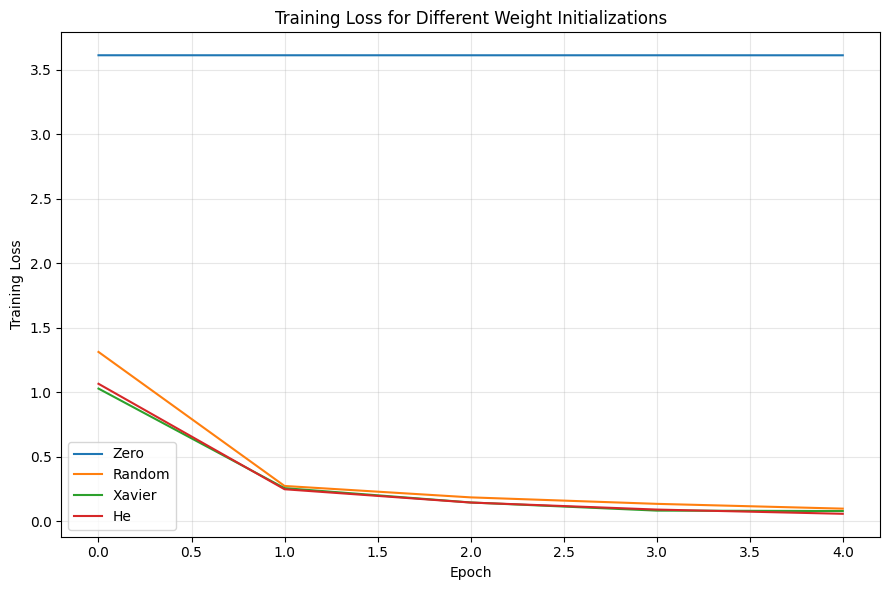

In [21]:
plt.figure(figsize=(9, 6))

for name, history in initialization_histories.items():

    plt.plot(
        history["loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Weight Initializations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/plot1_initialization_training_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

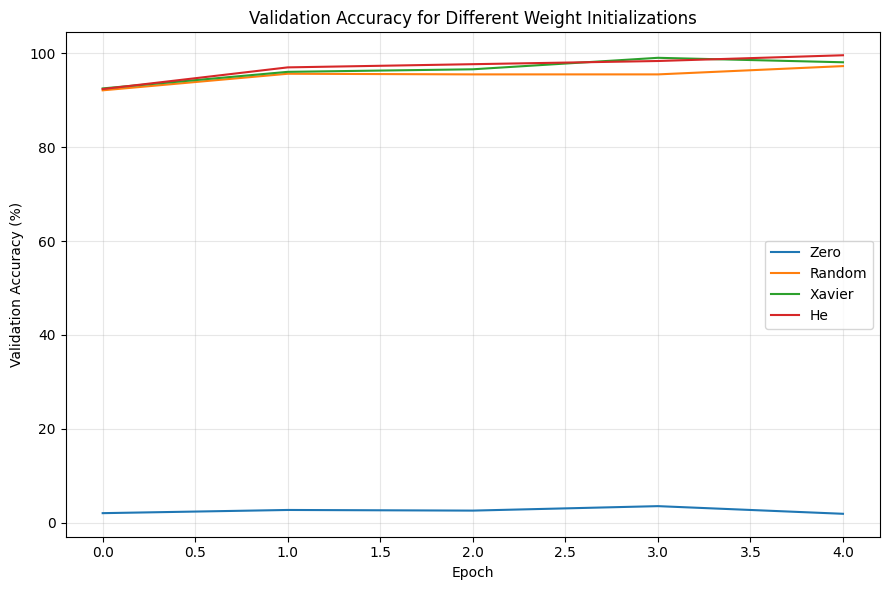

In [22]:
plt.figure(figsize=(9, 6))

for name, history in initialization_histories.items():

    accuracy = np.array(
        history["val_accuracy"]
    ) * 100

    plt.plot(
        accuracy,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy for Different Weight Initializations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/plot2_initialization_validation_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [23]:
best_initialization = max(
    initialization_results,
    key=lambda x:
        initialization_results[x]["Best Validation Accuracy"]
)

print(
    "Best initialization:",
    best_initialization
)

print(
    "Best validation accuracy:",
    f"{initialization_results[best_initialization]['Best Validation Accuracy'] * 100:.2f}%"
)

Best initialization: He
Best validation accuracy: 99.59%


In [24]:
regularization_configs = {

    "No Regularization": {
        "regularization": None,
        "dropout": 0.0,
        "batch_norm": False
    },

    "L2": {
        "regularization": l2(0.001),
        "dropout": 0.0,
        "batch_norm": False
    },

    "Dropout": {
        "regularization": None,
        "dropout": 0.5,
        "batch_norm": False
    },

    "Batch Normalization": {
        "regularization": None,
        "dropout": 0.0,
        "batch_norm": True
    }
}

regularization_histories = {}
regularization_results = {}

for name, config in regularization_configs.items():

    print("\n" + "=" * 60)
    print("Regularization:", name)
    print("=" * 60)

    model = build_model(
        **config
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    elapsed = time.time() - start

    regularization_histories[name] = history.history

    regularization_results[name] = {
        "Best Validation Accuracy":
            max(history.history["val_accuracy"]),
        "Training Time": elapsed
    }

    cleanup_model(model)


Regularization: No Regularization
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - accuracy: 0.7126 - loss: 1.0750 - val_accuracy: 0.9022 - val_loss: 0.2995
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9263 - loss: 0.2442 - val_accuracy: 0.9552 - val_loss: 0.1505
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9664 - loss: 0.1266 - val_accuracy: 0.9810 - val_loss: 0.0818
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9810 - loss: 0.0861 - val_accuracy: 0.9878 - val_loss: 0.0707
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9878 - loss: 0.0596 - val_accuracy: 0.9851 - val_loss: 0.0535

Regularization: L2
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 129ms/step - accuracy: 0.7385 - loss: 1.2862 - val_accuracy: 0.8940 - val_loss: 0.5851
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9188 - loss: 0.5020 - val_accuracy: 0.9497 - val_loss: 0.4082
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - a

In [25]:
regularization_table = pd.DataFrame(
    regularization_results
).T

regularization_table["Best Validation Accuracy (%)"] = (
    regularization_table["Best Validation Accuracy"] * 100
)

regularization_table

,Best Validation Accuracy,Training Time,Best Validation Accuracy (%)
No Regularization,0.987772,68.598129,98.777175
L2,0.989130,69.335806,98.913044
Dropout,0.959239,68.684144,95.923913
Batch Normalization,0.994565,69.236097,99.456519


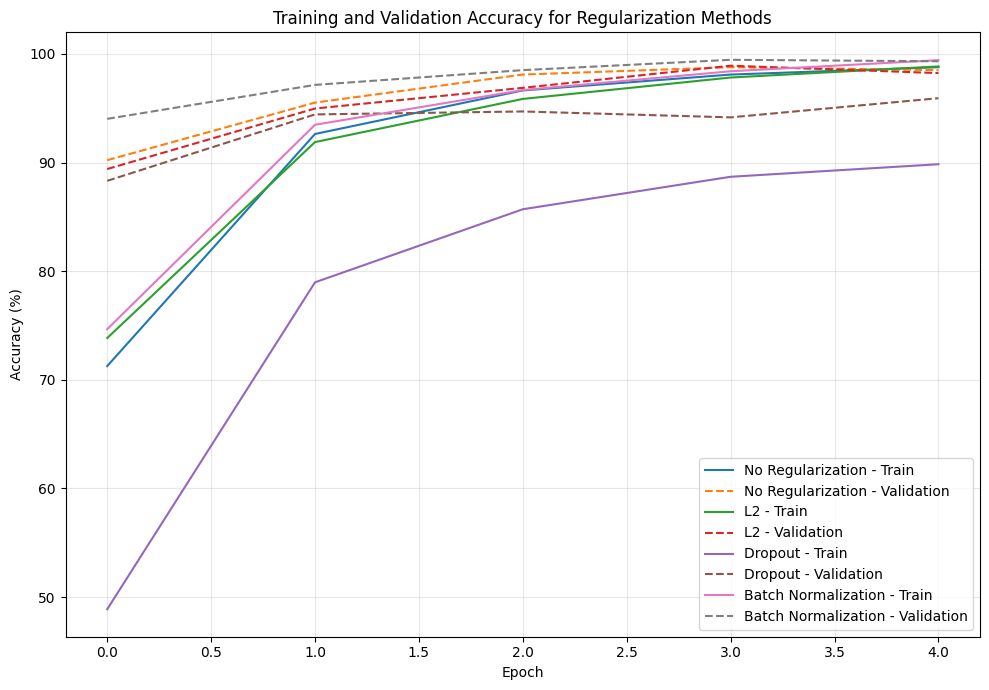

In [26]:
plt.figure(figsize=(10, 7))

for name, history in regularization_histories.items():

    plt.plot(
        np.array(history["accuracy"]) * 100,
        label=f"{name} - Train"
    )

    plt.plot(
        np.array(history["val_accuracy"]) * 100,
        linestyle="--",
        label=f"{name} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy for Regularization Methods")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/plot3_regularization_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

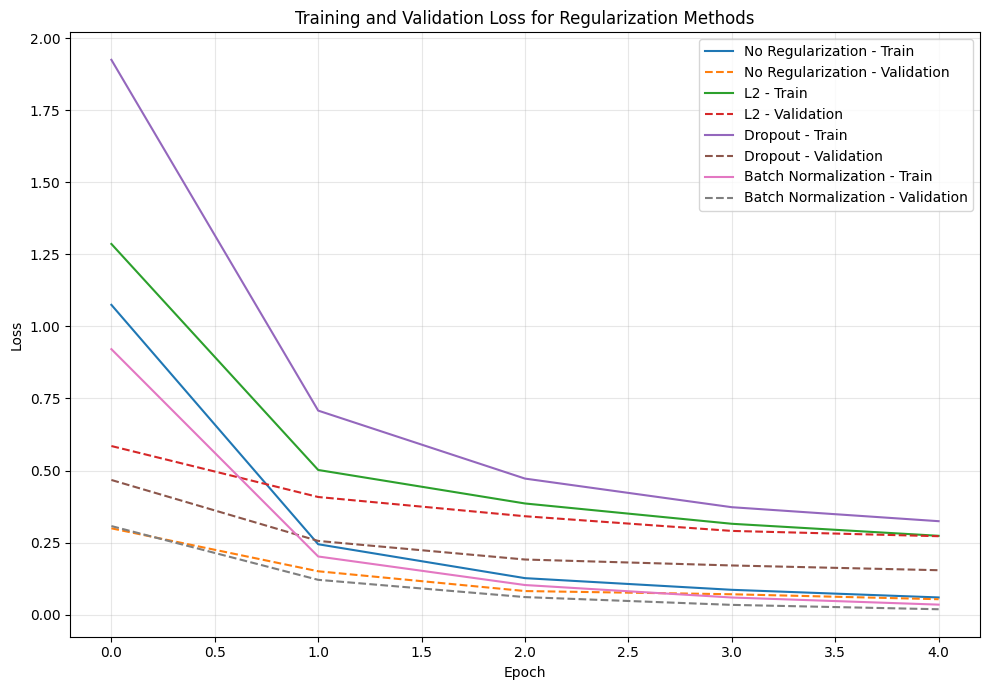

In [27]:
plt.figure(figsize=(10, 7))

for name, history in regularization_histories.items():

    plt.plot(
        history["loss"],
        label=f"{name} - Train"
    )

    plt.plot(
        history["val_loss"],
        linestyle="--",
        label=f"{name} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss for Regularization Methods")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/plot4_regularization_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

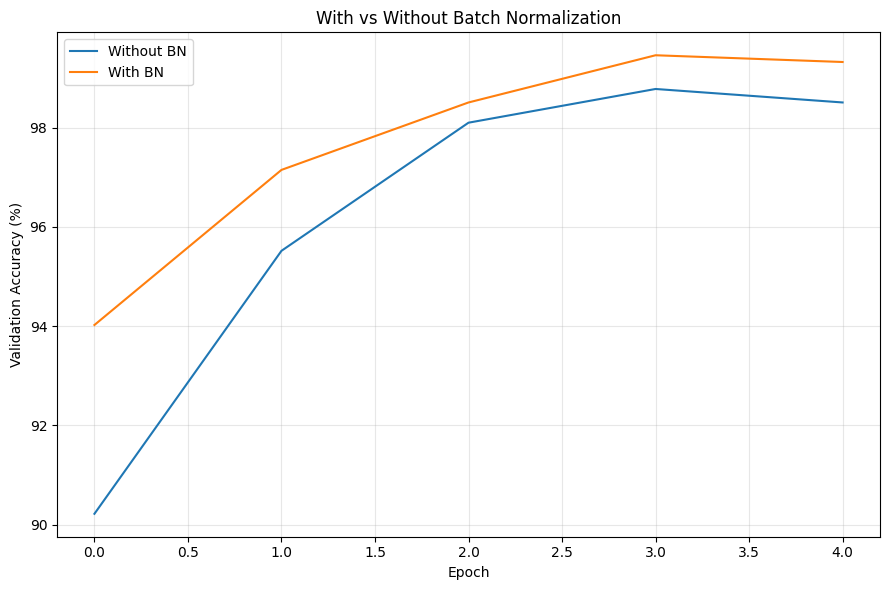

In [28]:
plt.figure(figsize=(9, 6))

without_bn = (
    np.array(
        regularization_histories[
            "No Regularization"
        ]["val_accuracy"]
    ) * 100
)

with_bn = (
    np.array(
        regularization_histories[
            "Batch Normalization"
        ]["val_accuracy"]
    ) * 100
)

plt.plot(
    without_bn,
    label="Without BN"
)

plt.plot(
    with_bn,
    label="With BN"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("With vs Without Batch Normalization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/plot5_batch_normalization.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [29]:
optimizer_names = [
    "SGD",
    "Momentum",
    "RMSProp",
    "Adam"
]

optimizer_histories = {}
optimizer_results = {}

for optimizer_name in optimizer_names:

    print("\n" + "=" * 60)
    print("Optimizer:", optimizer_name)
    print("=" * 60)

    if optimizer_name == "SGD":

        optimizer = SGD(
            learning_rate=0.001
        )

    elif optimizer_name == "Momentum":

        optimizer = SGD(
            learning_rate=0.001,
            momentum=0.9
        )

    elif optimizer_name == "RMSProp":

        optimizer = RMSprop(
            learning_rate=0.001
        )

    else:

        optimizer = Adam(
            learning_rate=0.001
        )

    model = build_model()

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    elapsed = time.time() - start

    optimizer_histories[
        optimizer_name
    ] = history.history

    val_acc = np.array(
        history.history["val_accuracy"]
    )

    best_epoch = int(
        np.argmax(val_acc)
    ) + 1

    optimizer_results[
        optimizer_name
    ] = {

        "Final Loss":
            history.history["loss"][-1],

        "Best Validation Accuracy":
            np.max(val_acc),

        "Epoch to Best Validation Accuracy":
            best_epoch,

        "Training Time":
            elapsed
    }

    cleanup_model(model)


Optimizer: SGD
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - accuracy: 0.0156 - loss: 3.7839 - val_accuracy: 0.0299 - val_loss: 3.6172
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.0516 - loss: 3.5108 - val_accuracy: 0.0965 - val_loss: 3.3760
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.1250 - loss: 3.2894 - val_accuracy: 0.1848 - val_loss: 3.1674
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.2021 - loss: 3.1006 - val_accuracy: 0.2622 - val_loss: 2.9714
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.2874 - loss: 2.9199 - val_accuracy: 0.3764 - val_loss: 2.7607

Optimizer: Momentum
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.2242 - loss: 3.1430 - val_accuracy: 0.5217 - val_loss: 2.2409
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.7092 - loss: 1.5960 - val_accuracy: 0.8302 - val_loss: 1.0381
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.8502 - 

In [30]:
optimizer_table = pd.DataFrame(
    optimizer_results
).T

optimizer_table[
    "Best Validation Accuracy (%)"
] = (
    optimizer_table[
        "Best Validation Accuracy"
    ] * 100
)

optimizer_table

,Final Loss,Best Validation Accuracy,Epoch to Best Validation Accuracy,Training Time,Best Validation Accuracy (%)
SGD,2.919882,0.376359,5.0,69.647111,37.635869
Momentum,0.439672,0.919837,4.0,68.480045,91.983694
RMSProp,0.065422,0.986413,4.0,69.493622,98.641306
Adam,0.078226,0.987772,5.0,68.457582,98.777175


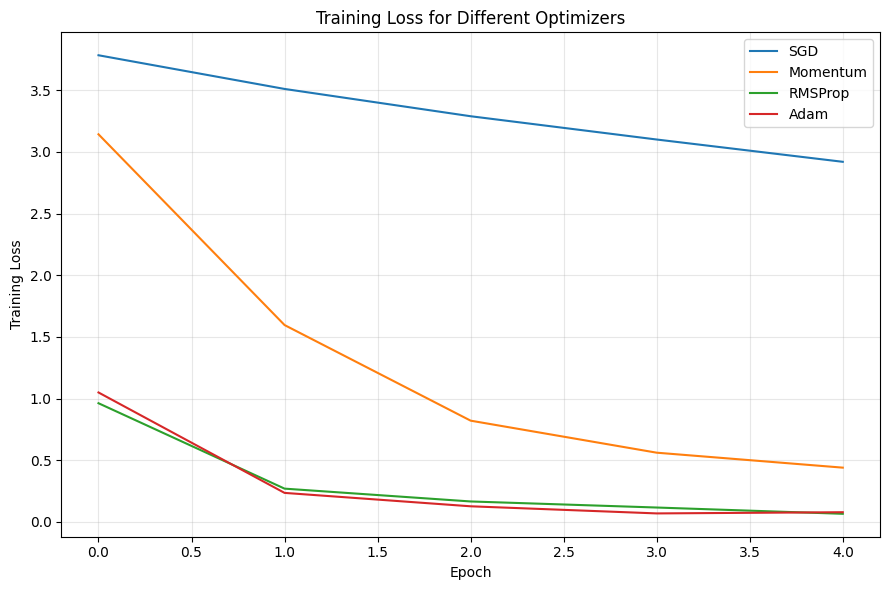

In [31]:
plt.figure(figsize=(9, 6))

for name, history in optimizer_histories.items():

    plt.plot(
        history["loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Optimizers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/plot6_optimizer_training_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

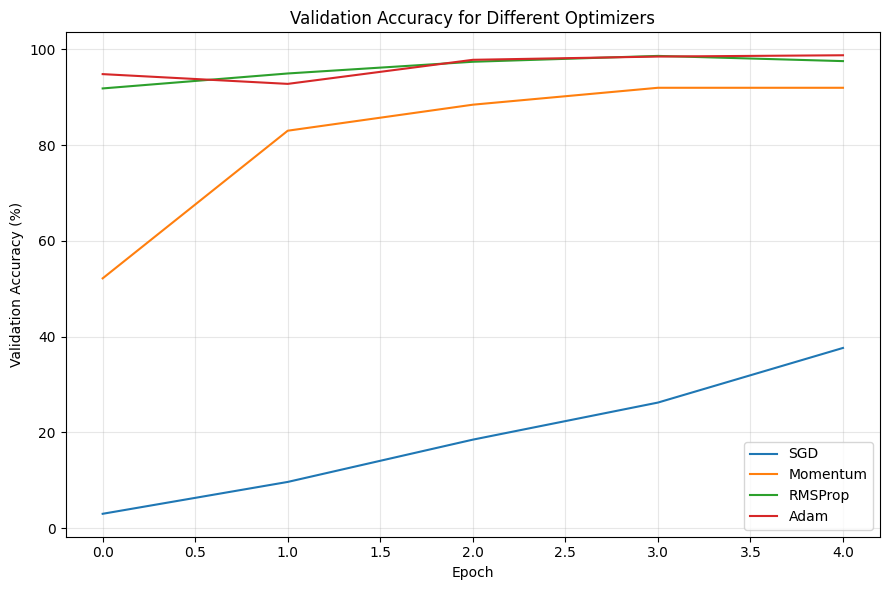

In [32]:
plt.figure(figsize=(9, 6))

for name, history in optimizer_histories.items():

    plt.plot(
        np.array(
            history["val_accuracy"]
        ) * 100,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy for Different Optimizers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/plot7_optimizer_validation_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [33]:
best_optimizer = max(
    optimizer_results,
    key=lambda x:
        optimizer_results[x][
            "Best Validation Accuracy"
        ]
)

print(
    "Best optimizer:",
    best_optimizer
)

print(
    "Best validation accuracy:",
    f"{optimizer_results[best_optimizer]['Best Validation Accuracy'] * 100:.2f}%"
)

Best optimizer: Adam
Best validation accuracy: 98.78%


In [34]:
learning_rates = [
    0.001,
    0.0001
]

learning_rate_results = {}

for lr in learning_rates:

    print("\nLearning Rate:", lr)

    model = build_model()

    model.compile(
        optimizer=Adam(
            learning_rate=lr
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    learning_rate_results[lr] = max(
        history.history["val_accuracy"]
    )

    cleanup_model(model)

print(learning_rate_results)


Learning Rate: 0.001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.7334 - loss: 1.0413 - val_accuracy: 0.9307 - val_loss: 0.2608
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.9304 - loss: 0.2478 - val_accuracy: 0.9647 - val_loss: 0.1573
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9643 - loss: 0.1324 - val_accuracy: 0.9688 - val_loss: 0.1120
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9762 - loss: 0.0895 - val_accuracy: 0.9783 - val_loss: 0.0765
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9901 - loss: 0.0498 - val_accuracy: 0.9918 - val_loss: 0.0429

Learning Rate: 0.0001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.1990 - loss: 3.1392 - val_accuracy: 0.5489 - val_loss: 2.2758
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.7072 - loss: 1.6563 - val_accuracy: 0.8125 - val_loss: 1.1144
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0

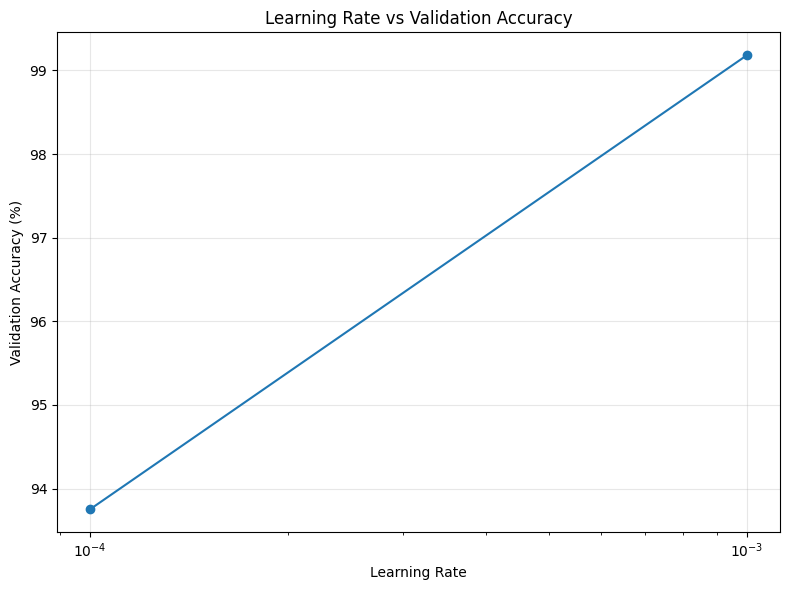

In [35]:
lr_values = list(
    learning_rate_results.keys()
)

lr_accuracy = [
    learning_rate_results[x] * 100
    for x in lr_values
]

plt.figure(figsize=(8, 6))

plt.plot(
    lr_values,
    lr_accuracy,
    marker="o"
)

plt.xscale("log")

plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Learning Rate vs Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/plot8_learning_rate.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [36]:
batch_sizes = [
    16,
    32,
    64
]

batch_size_results = {}

for bs in batch_sizes:

    print("\nBatch Size:", bs)

    current_train_ds = make_dataset(
        train_only_raw,
        batch_size=bs,
        shuffle=True
    )

    model = build_model()

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        current_train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    batch_size_results[bs] = max(
        history.history["val_accuracy"]
    )

    del current_train_ds

    cleanup_model(model)


Batch Size: 16
Epoch 1/5


2026-08-27 04:28:17.475295: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 04:28:17.629307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 04:28:17.766123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


184/184 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.7568 - loss: 0.9065 - val_accuracy: 0.9348 - val_loss: 0.2461
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.9324 - loss: 0.2269 - val_accuracy: 0.9620 - val_loss: 0.1328
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.9694 - loss: 0.1131 - val_accuracy: 0.9620 - val_loss: 0.1050
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.9762 - loss: 0.0801 - val_accuracy: 0.9864 - val_loss: 0.0694
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.9881 - loss: 0.0538 - val_accuracy: 0.9796 - val_loss: 0.0654

Batch Size: 32
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.7198 - loss: 1.0396 - val_accuracy: 0.9389 - val_loss: 0.2309
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.9273 - loss: 0.2398 - val_accuracy: 0.9307 - val_loss: 0.2219
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.9681 - loss: 0.1302 - val_acc

2026-08-27 04:30:54.366575: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 04:30:54.505559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


46/46 ━━━━━━━━━━━━━━━━━━━━ 33s 257ms/step - accuracy: 0.6624 - loss: 1.3607 - val_accuracy: 0.8818 - val_loss: 0.3916
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.9161 - loss: 0.2830 - val_accuracy: 0.9416 - val_loss: 0.1921
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.9562 - loss: 0.1631 - val_accuracy: 0.9728 - val_loss: 0.1153
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.9738 - loss: 0.1153 - val_accuracy: 0.9620 - val_loss: 0.1205
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.9857 - loss: 0.0795 - val_accuracy: 0.9823 - val_loss: 0.0849


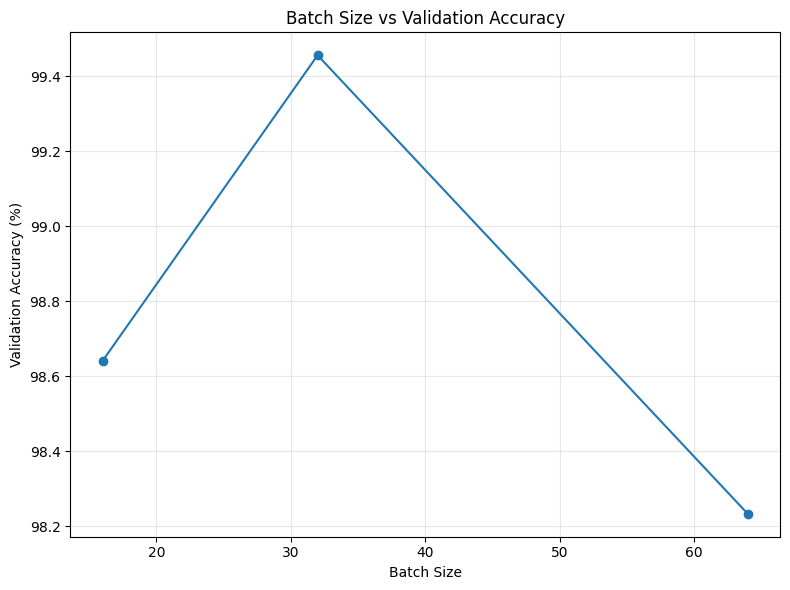

In [37]:
bs_values = list(
    batch_size_results.keys()
)

bs_accuracy = [
    batch_size_results[x] * 100
    for x in bs_values
]

plt.figure(figsize=(8, 6))

plt.plot(
    bs_values,
    bs_accuracy,
    marker="o"
)

plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Batch Size vs Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/plot9_batch_size.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [38]:
dropout_rates = [
    0.0,
    0.25,
    0.5
]

dropout_results = {}

for rate in dropout_rates:

    print("\nDropout:", rate)

    model = build_model(
        dropout=rate
    )

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    dropout_results[rate] = max(
        history.history["val_accuracy"]
    )

    cleanup_model(model)


Dropout: 0.0
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 131ms/step - accuracy: 0.7174 - loss: 1.1022 - val_accuracy: 0.9090 - val_loss: 0.3103
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9215 - loss: 0.2649 - val_accuracy: 0.9389 - val_loss: 0.1813
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9565 - loss: 0.1446 - val_accuracy: 0.9701 - val_loss: 0.1029
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9796 - loss: 0.0907 - val_accuracy: 0.9688 - val_loss: 0.1084
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9901 - loss: 0.0581 - val_accuracy: 0.9973 - val_loss: 0.0401

Dropout: 0.25
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.6542 - loss: 1.2959 - val_accuracy: 0.9022 - val_loss: 0.3474
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.8770 - loss: 0.4177 - val_accuracy: 0.9429 - val_loss: 0.1964
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9113 - loss: 0.

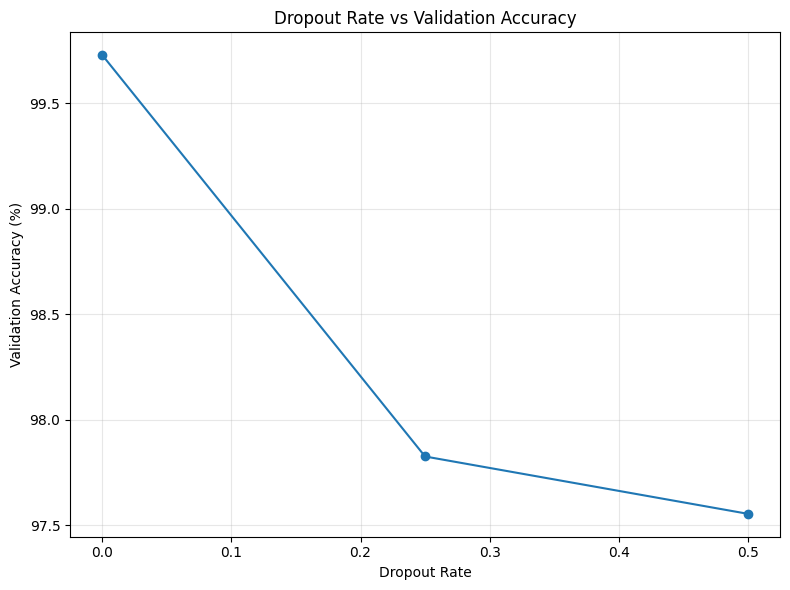

In [39]:
dropout_values = list(
    dropout_results.keys()
)

dropout_accuracy = [
    dropout_results[x] * 100
    for x in dropout_values
]

plt.figure(figsize=(8, 6))

plt.plot(
    dropout_values,
    dropout_accuracy,
    marker="o"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Dropout Rate vs Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/plot10_dropout.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [40]:
feature_model = build_model(
    base_trainable=False
)

feature_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

feature_start = time.time()

feature_history = feature_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

feature_time = (
    time.time() - feature_start
)

print(
    "Feature extraction time:",
    f"{feature_time:.2f} seconds"
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 134ms/step - accuracy: 0.7337 - loss: 1.0343 - val_accuracy: 0.8995 - val_loss: 0.3264
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.9276 - loss: 0.2407 - val_accuracy: 0.9524 - val_loss: 0.1581
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.9541 - loss: 0.1470 - val_accuracy: 0.9796 - val_loss: 0.0863
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.9738 - loss: 0.0974 - val_accuracy: 0.9878 - val_loss: 0.0750
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9925 - loss: 0.0490 - val_accuracy: 0.9918 - val_loss: 0.0541
Feature extraction time: 69.91 seconds


In [41]:
fine_model = build_model(
    base_trainable=True,
    fine_tune_layers=30
)

fine_model.compile(
    optimizer=Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_start = time.time()

fine_history = fine_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    verbose=1
)

fine_time = (
    time.time() - fine_start
)

print(
    "Fine-tuning time:",
    f"{fine_time:.2f} seconds"
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 138ms/step - accuracy: 0.0564 - loss: 3.6057 - val_accuracy: 0.1046 - val_loss: 3.2757
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.2320 - loss: 2.9696 - val_accuracy: 0.3505 - val_loss: 2.6671
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.5024 - loss: 2.3889 - val_accuracy: 0.5761 - val_loss: 2.1658
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.6658 - loss: 1.8688 - val_accuracy: 0.7541 - val_loss: 1.5502
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.7707 - loss: 1.4056 - val_accuracy: 0.8234 - val_loss: 1.1498
Fine-tuning time: 79.01 seconds


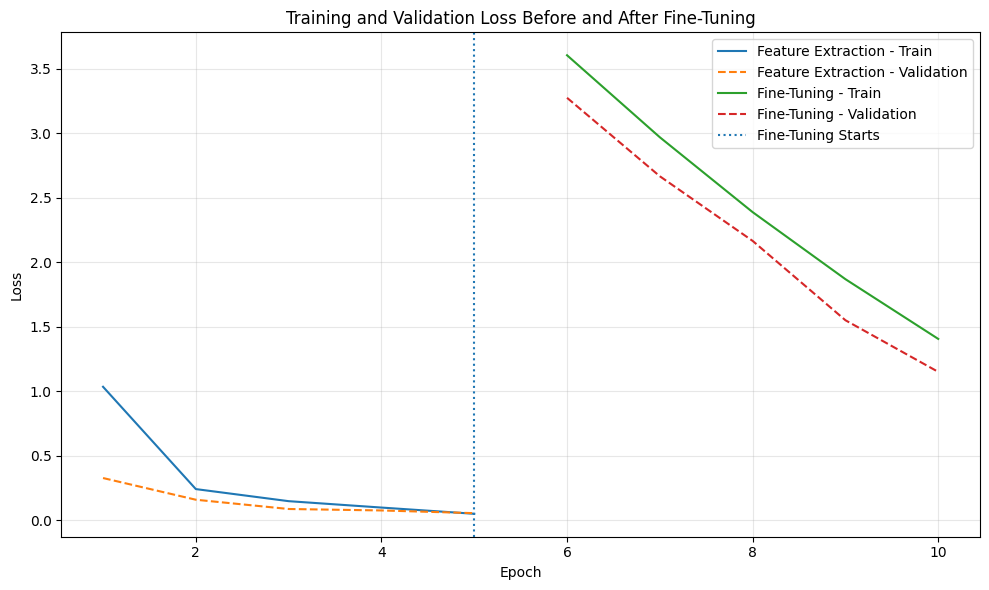

In [42]:
feature_train_loss = (
    feature_history.history["loss"]
)

feature_val_loss = (
    feature_history.history["val_loss"]
)

fine_train_loss = (
    fine_history.history["loss"]
)

fine_val_loss = (
    fine_history.history["val_loss"]
)

feature_epochs = np.arange(
    1,
    len(feature_train_loss) + 1
)

fine_epochs = np.arange(
    len(feature_train_loss) + 1,
    len(feature_train_loss)
    + len(fine_train_loss) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    feature_epochs,
    feature_train_loss,
    label="Feature Extraction - Train"
)

plt.plot(
    feature_epochs,
    feature_val_loss,
    linestyle="--",
    label="Feature Extraction - Validation"
)

plt.plot(
    fine_epochs,
    fine_train_loss,
    label="Fine-Tuning - Train"
)

plt.plot(
    fine_epochs,
    fine_val_loss,
    linestyle="--",
    label="Fine-Tuning - Validation"
)

plt.axvline(
    len(feature_train_loss),
    linestyle=":",
    label="Fine-Tuning Starts"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Before and After Fine-Tuning")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/plot12_finetuning_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [43]:
cleanup_model(feature_model)
cleanup_model(fine_model)

del feature_history
del fine_history

gc.collect()

print("Transfer learning models cleared from memory.")

Transfer learning models cleared from memory.


In [44]:
train_count = TRAIN_COUNT

all_indices = np.arange(
    train_count
)

print(
    "Number of training indices:",
    len(all_indices)
)

Number of training indices: 2944


In [45]:
cv_configs = {

    "C1": {
        "lr": 0.001,
        "dropout": 0.0,
        "batch": 32
    },

    "C2": {
        "lr": 0.001,
        "dropout": 0.25,
        "batch": 32
    },

    "C3": {
        "lr": 0.0001,
        "dropout": 0.25,
        "batch": 32
    },

    "C4": {
        "lr": 0.0001,
        "dropout": 0.5,
        "batch": 32
    }
}

pd.DataFrame(cv_configs).T

,lr,dropout,batch
C1,0.0010,0.00,32.0
C2,0.0010,0.25,32.0
C3,0.0001,0.25,32.0
C4,0.0001,0.50,32.0


In [46]:
def make_fold_dataset(
    raw_dataset,
    selected_indices,
    batch_size,
    shuffle=False
):

    selected_indices = np.asarray(
        selected_indices,
        dtype=np.int32
    )

    index_set = tf.constant(
        selected_indices
    )

    indexed_dataset = raw_dataset.enumerate()

    def keep_index(index, data):

        return tf.reduce_any(
            tf.equal(
                tf.cast(index, tf.int32),
                index_set
            )
        )

    dataset = indexed_dataset.filter(
        keep_index
    )

    dataset = dataset.map(
        lambda index, data: data,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:

        dataset = dataset.shuffle(
            500,
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(
        batch_size
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [47]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_results = {}

for config_name, config in cv_configs.items():

    print("\n")
    print("#" * 70)
    print("Configuration:", config_name)
    print(config)
    print("#" * 70)

    fold_scores = []

    for fold_number, (
        train_indices,
        validation_indices
    ) in enumerate(
        kfold.split(all_indices),
        start=1
    ):

        print(
            f"\nFold {fold_number}/5"
        )

        fold_train_ds = make_fold_dataset(
            train_only_raw,
            train_indices,
            config["batch"],
            shuffle=True
        )

        fold_val_ds = make_fold_dataset(
            train_only_raw,
            validation_indices,
            config["batch"],
            shuffle=False
        )

        model = build_model(
            dropout=config["dropout"]
        )

        model.compile(
            optimizer=Adam(
                learning_rate=config["lr"]
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history = model.fit(
            fold_train_ds,
            validation_data=fold_val_ds,
            epochs=CV_EPOCHS,
            verbose=0
        )

        best_fold_accuracy = max(
            history.history["val_accuracy"]
        )

        fold_scores.append(
            best_fold_accuracy
        )

        print(
            f"Fold {fold_number} accuracy: "
            f"{best_fold_accuracy * 100:.2f}%"
        )

        del fold_train_ds
        del fold_val_ds
        del history

        cleanup_model(model)

    mean_score = np.mean(
        fold_scores
    )

    std_score = np.std(
        fold_scores
    )

    cv_results[config_name] = {
        "F1": fold_scores[0],
        "F2": fold_scores[1],
        "F3": fold_scores[2],
        "F4": fold_scores[3],
        "F5": fold_scores[4],
        "Mean": mean_score,
        "SD": std_score
    }

    print(
        f"\n{config_name} Mean: "
        f"{mean_score * 100:.2f}%"
    )

    print(
        f"{config_name} SD: "
        f"{std_score * 100:.2f}%"
    )



######################################################################
Configuration: C1
{'lr': 0.001, 'dropout': 0.0, 'batch': 32}
######################################################################

Fold 1/5


2026-08-27 04:39:46.309443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 04:39:46.446348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-08-27 04:40:05.540157: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing war

Fold 1 accuracy: 95.42%

Fold 2/5
Fold 2 accuracy: 96.26%

Fold 3/5
Fold 3 accuracy: 95.59%

Fold 4/5
Fold 4 accuracy: 94.74%

Fold 5/5


2026-08-27 04:43:35.031949: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 04:43:35.168924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 04:43:54.248906: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 04:43:54.396665: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 04:43:54.534993: E external/local_xla/xla/stream_

Fold 5 accuracy: 94.90%

C1 Mean: 95.38%
C1 SD: 0.54%


######################################################################
Configuration: C2
{'lr': 0.001, 'dropout': 0.25, 'batch': 32}
######################################################################

Fold 1/5
Fold 1 accuracy: 94.91%

Fold 2/5
Fold 2 accuracy: 95.76%

Fold 3/5
Fold 3 accuracy: 95.08%

Fold 4/5
Fold 4 accuracy: 95.25%

Fold 5/5
Fold 5 accuracy: 94.05%

C2 Mean: 95.01%
C2 SD: 0.56%


######################################################################
Configuration: C3
{'lr': 0.0001, 'dropout': 0.25, 'batch': 32}
######################################################################

Fold 1/5
Fold 1 accuracy: 79.97%

Fold 2/5
Fold 2 accuracy: 80.81%

Fold 3/5
Fold 3 accuracy: 79.63%

Fold 4/5
Fold 4 accuracy: 82.17%

Fold 5/5
Fold 5 accuracy: 80.27%

C3 Mean: 80.57%
C3 SD: 0.89%


######################################################################
Configuration: C4
{'lr': 0.0001, 'dropout': 0.5, 'batch': 32

In [48]:
cv_table = pd.DataFrame(
    cv_results
).T

display(cv_table)

,F1,F2,F3,F4,F5,Mean,SD
C1,0.954160,0.962649,0.955857,0.947368,0.948980,0.953803,0.005427
C2,0.949066,0.957555,0.950764,0.952462,0.940476,0.950065,0.005573
C3,0.799660,0.808149,0.796265,0.821732,0.802721,0.805705,0.008915
C4,0.730051,0.707980,0.662139,0.718166,0.765306,0.716728,0.033454


In [49]:
cv_percentage_table = (
    cv_table * 100
)

cv_percentage_table = (
    cv_percentage_table.round(2)
)

cv_percentage_table

,F1,F2,F3,F4,F5,Mean,SD
C1,95.42,96.26,95.59,94.74,94.90,95.38,0.54
C2,94.91,95.76,95.08,95.25,94.05,95.01,0.56
C3,79.97,80.81,79.63,82.17,80.27,80.57,0.89
C4,73.01,70.80,66.21,71.82,76.53,71.67,3.35


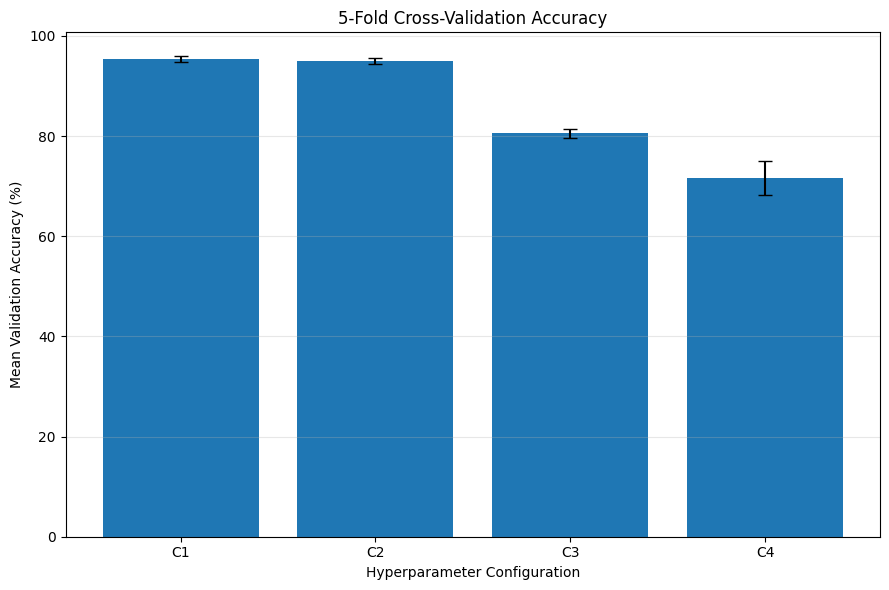

In [50]:
plt.figure(figsize=(9, 6))

means = (
    cv_table["Mean"].values * 100
)

stds = (
    cv_table["SD"].values * 100
)

plt.bar(
    cv_table.index,
    means,
    yerr=stds,
    capsize=5
)

plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "images/plot13_cross_validation.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [51]:
best_config_name = cv_table[
    "Mean"
].idxmax()

best_config = cv_configs[
    best_config_name
]

print(
    "Best configuration:",
    best_config_name
)

print(
    "Configuration:",
    best_config
)

print(
    "Mean CV Accuracy:",
    f"{cv_table.loc[best_config_name, 'Mean'] * 100:.2f}%"
)

print(
    "CV Standard Deviation:",
    f"{cv_table.loc[best_config_name, 'SD'] * 100:.2f}%"
)

Best configuration: C1
Configuration: {'lr': 0.001, 'dropout': 0.0, 'batch': 32}
Mean CV Accuracy: 95.38%
CV Standard Deviation: 0.54%


In [52]:
development_raw = train_only_raw.concatenate(
    val_raw
)

development_count = (
    TRAIN_COUNT + VAL_COUNT
)

print(
    "Final development set:",
    development_count
)

print(
    "Independent test set:",
    tf.data.experimental.cardinality(
        test_raw
    ).numpy()
)

Final development set: 3680
Independent test set: 3669


In [53]:
development_ds = make_dataset(
    development_raw,
    batch_size=best_config["batch"],
    shuffle=True
)

print(
    "Final development dataset ready."
)

Final development dataset ready.


In [54]:
final_model = build_model(
    dropout=best_config["dropout"]
)

final_model.compile(
    optimizer=Adam(
        learning_rate=best_config["lr"]
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,725 (9.26 MB)

 Trainable params: 168,741 (659.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [55]:
final_start = time.time()

final_history = final_model.fit(
    development_ds,
    epochs=EPOCHS,
    verbose=1
)

final_training_time = (
    time.time() - final_start
)

print(
    f"\nFinal training time: "
    f"{final_training_time:.2f} seconds"
)

Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.7590 - loss: 0.9332
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9348 - loss: 0.2141
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9696 - loss: 0.1149
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9859 - loss: 0.0615
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9921 - loss: 0.0421

Final training time: 64.29 seconds


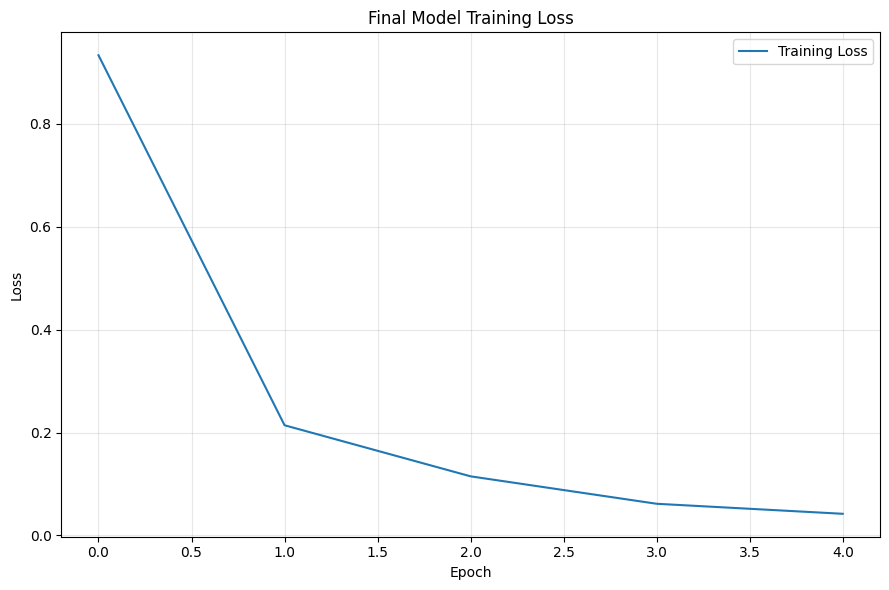

In [56]:
plt.figure(figsize=(9, 6))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/final_training_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [57]:
test_loss, test_accuracy = (
    final_model.evaluate(
        test_ds,
        verbose=1
    )
)

print(
    "Test Loss:",
    test_loss
)

print(
    "Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

113/115 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8984 - loss: 0.3501

2026-08-27 05:01:23.104229: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 05:01:23.256863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 05:01:23.393932: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - accuracy: 0.8989 - loss: 0.3484
Test Loss: 0.3484184443950653
Test Accuracy: 89.89%


In [58]:
true_labels = []
predicted_labels = []

for batch_images, batch_labels in test_ds:

    probabilities = final_model.predict(
        batch_images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    true_labels.extend(
        batch_labels.numpy()
    )

    predicted_labels.extend(
        predictions
    )

true_labels = np.array(
    true_labels
)

predicted_labels = np.array(
    predicted_labels
)

print(
    "Number of test predictions:",
    len(predicted_labels)
)

Number of test predictions: 3669


In [59]:
test_precision = precision_score(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

print(
    f"Accuracy : {test_accuracy * 100:.2f}%"
)

print(
    f"Precision: {test_precision * 100:.2f}%"
)

print(
    f"Recall   : {test_recall * 100:.2f}%"
)

print(
    f"F1-score : {test_f1 * 100:.2f}%"
)

Accuracy : 89.89%
Precision: 90.30%
Recall   : 89.89%
F1-score : 89.83%


In [60]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.7395    0.8980    0.8111        98
           1     0.7073    0.8700    0.7803       100
           2     0.7746    0.5500    0.6433       100
           3     0.9770    0.8500    0.9091       100
           4     0.8220    0.9700    0.8899       100
           5     0.7542    0.8900    0.8165       100
           6     0.7686    0.9300    0.8416       100
           7     0.8723    0.9318    0.9011        88
           8     0.8830    0.8384    0.8601        99
           9     0.8837    0.7600    0.8172       100
          10     0.9659    0.8500    0.9043       100
          11     0.9500    0.7835    0.8588        97
          12     0.9694    0.9500    0.9596       100
          13     0.9792    0.9400    0.9592       100
          14     0.8991    0.9800    0.9378       100
          15     0.9899    0.9800    0.9849       100
          16     0.9238    0.9700    0.9463       100
          17     1.0000    

In [61]:
final_results = pd.DataFrame({

    "Metric": [
        "Mean CV Accuracy",
        "CV Standard Deviation",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (seconds)",
        "Number of Parameters"
    ],

    "Value": [

        cv_table.loc[
            best_config_name,
            "Mean"
        ] * 100,

        cv_table.loc[
            best_config_name,
            "SD"
        ] * 100,

        test_accuracy * 100,

        test_precision * 100,

        test_recall * 100,

        test_f1 * 100,

        final_training_time,

        final_model.count_params()
    ]
})

final_results

,Metric,Value
0,Mean CV Accuracy,9.538027e+01
1,CV Standard Deviation,5.426977e-01
2,Test Accuracy,8.988825e+01
3,Precision,9.029896e+01
4,Recall,8.988825e+01
5,F1-score,8.982960e+01
6,Training Time (seconds),6.428545e+01
7,Number of Parameters,2.426725e+06


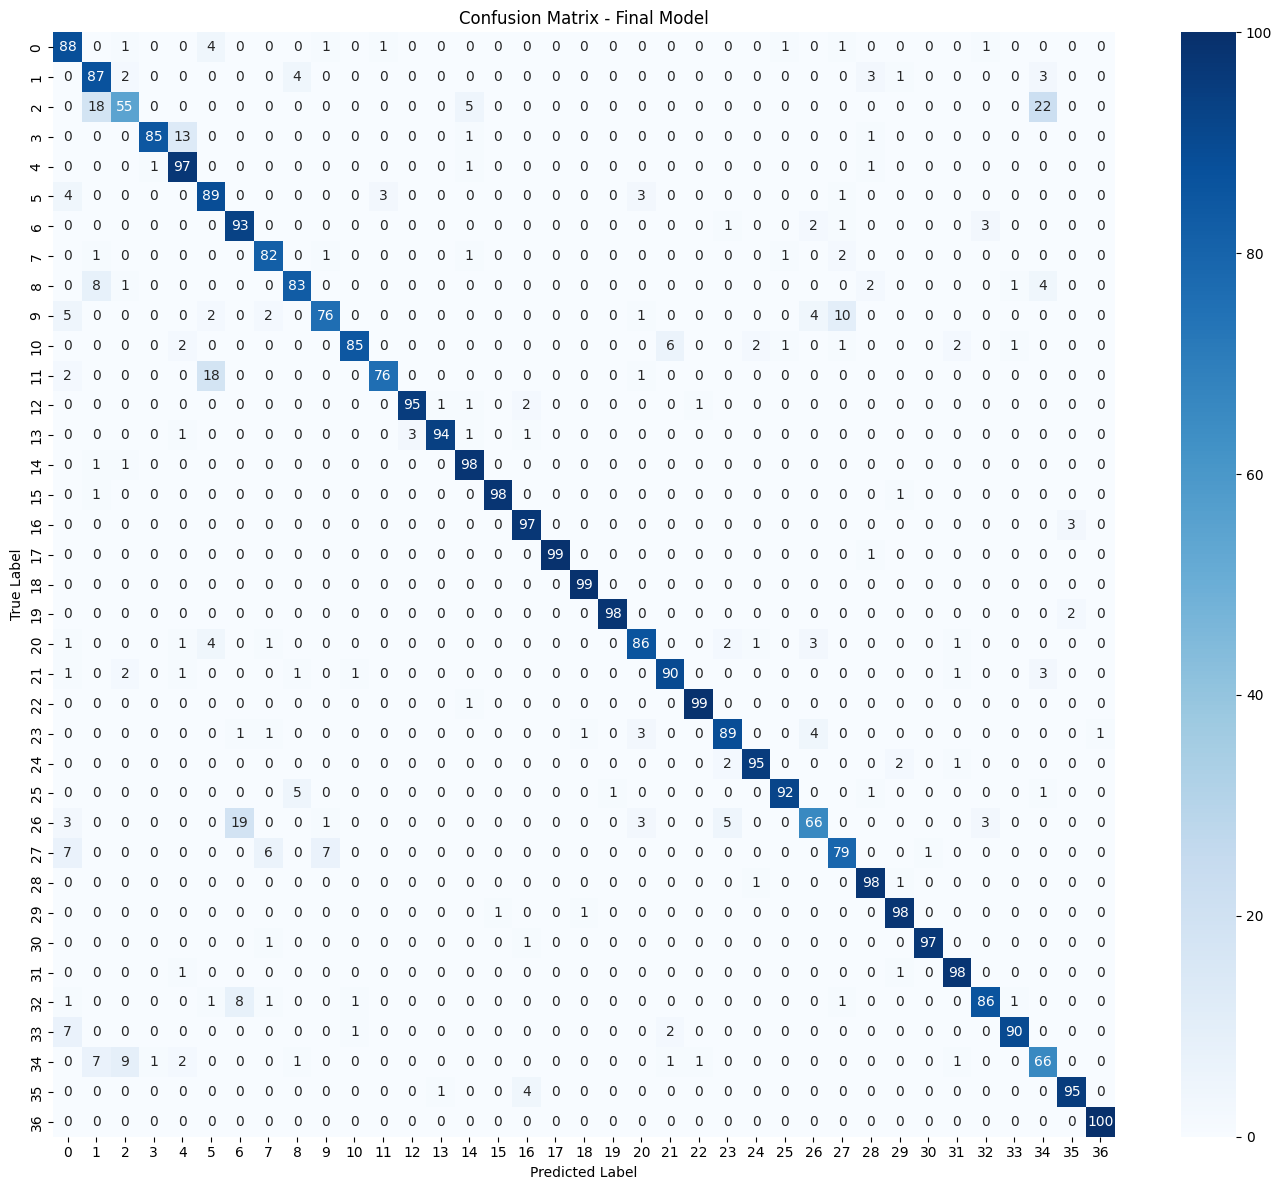

In [62]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(NUM_CLASSES),
    yticklabels=range(NUM_CLASSES)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Final Model")

plt.tight_layout()

plt.savefig(
    "images/plot14_confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [64]:
cm_without_diagonal = cm.copy()

np.fill_diagonal(
    cm_without_diagonal,
    0
)

most_confused = np.unravel_index(
    np.argmax(cm_without_diagonal),
    cm_without_diagonal.shape
)

true_class = most_confused[0]
predicted_class = most_confused[1]
confusion_count = cm_without_diagonal[
    most_confused
]

print(
    "Most frequently confused pair:"
)

print(
    f"True class {true_class} "
    f"→ Predicted class {predicted_class}"
)

print(
    "Number of confusions:",
    confusion_count
)

Most frequently confused pair:
True class 2 → Predicted class 34
Number of confusions: 22


In [67]:
class_correct = np.diag(cm)

class_totals = cm.sum(
    axis=1
)

class_accuracy = (
    class_correct /
    np.maximum(class_totals, 1)
)

best_classes = np.argsort(
    class_accuracy
)[-5:][::-1]

print(
    "Best classified classes:"
)

for cls in best_classes:

    print(
        f"Class {cls}: "
        f"{class_accuracy[cls] * 100:.2f}%"
    )

Best classified classes:
Class 36: 100.00%
Class 18: 100.00%
Class 22: 99.00%
Class 17: 99.00%
Class 31: 98.00%


In [69]:
# Get the fine-tuned model's validation accuracy
# using the existing validation dataset.

fine_eval_loss, fine_eval_accuracy = fine_model.evaluate(
    val_ds,
    verbose=0
)

print(
    f"Fine-Tuned Model Validation Accuracy: "
    f"{fine_eval_accuracy * 100:.2f}%"
)

Fine-Tuned Model Validation Accuracy: 82.34%


In [70]:
# Overall Results
# Compares the major experimental stages required by Lab 5.

best_regularization_name = max(
    regularization_results,
    key=lambda x:
    regularization_results[x][
        "Best Validation Accuracy"
    ]
)

best_regularization_accuracy = (
    regularization_results[
        best_regularization_name
    ]["Best Validation Accuracy"]
)

overall_results = pd.DataFrame({

    "Configuration": [
        "Baseline",
        "Best Initialization",
        "Best Regularization",
        "Best Optimizer",
        "Best Hyperparameters",
        "Fine-Tuned Model"
    ],

    "Validation / CV Accuracy (%)": [

        baseline_best_val * 100,

        initialization_results[
            best_initialization
        ]["Best Validation Accuracy"] * 100,

        best_regularization_accuracy * 100,

        optimizer_results[
            best_optimizer
        ]["Best Validation Accuracy"] * 100,

        cv_table.loc[
            best_config_name,
            "Mean"
        ] * 100,

        fine_eval_accuracy * 100
    ],

    "Training Time (s)": [

        baseline_time,

        initialization_results[
            best_initialization
        ]["Training Time"],

        regularization_results[
            best_regularization_name
        ]["Training Time"],

        optimizer_results[
            best_optimizer
        ]["Training Time"],

        np.nan,

        fine_time
    ]
})

display(overall_results)

,Configuration,Validation / CV Accuracy (%),Training Time (s)
0,Baseline,99.864131,77.055073
1,Best Initialization,99.592394,68.048373
2,Best Regularization,99.456519,69.236097
3,Best Optimizer,98.777175,68.457582
4,Best Hyperparameters,95.380273,NaN
5,Fine-Tuned Model,82.336956,79.013650
